In [1]:
# Team ID : PTID-AIE-MAR-26-11131#

In [2]:
# Project Ref: PM-PR-0017 #

# AIM : The aim of this project is to develop a Machine Learning model to identify customers likely to churn from telecom services and help the company improve customer retention strategies. The project also focuses on analyzing key factors influencing churn and generating a CHURN_FLAG for high-risk customers.

# Import Libraries

In [3]:
# ================================
# 📌 IMPORT LIBRARIES
# ================================

# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Handle Imbalanced Data
from imblearn.over_sampling import SMOTE

# ================================
# 📌 MACHINE LEARNING ALGORITHMS
# ================================

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Support Vector Machine
from sklearn.svm import SVC

# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier


# Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB

# ================================
# 📌 MODEL EVALUATION
# ================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# ================================
# 📌 SAVE MODEL
# ================================

import joblib

# ================================
# 📌 IGNORE WARNINGS
# ================================

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [4]:
!pip install pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 3.0 MB/s eta 0:00:00


In [5]:
import pymysql
import pandas as pd

conn = pymysql.connect(
    host="18.136.157.135",
    user="dm_team3",
    password="DM!$!Team!27@9!20&",
    database="project_telecom"
)

df = pd.read_sql("SELECT * FROM telecom_churn_data", conn)

df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [6]:
# Basic Exploration

In [7]:
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [8]:
df.tail()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
243548,243549,Airtel,F,28,Mizoram,Kolkata,110295,2023-05-03,3,130580,28,9,4102,0
243549,243550,Reliance Jio,F,52,Assam,Kolkata,713481,2023-05-03,0,82393,80,45,7521,0
243550,243551,Reliance Jio,M,59,Tripura,Kolkata,520218,2023-05-03,4,51298,26,4,6547,0
243551,243552,BSNL,M,49,Madhya Pradesh,Kolkata,387744,2023-05-03,2,83981,80,15,1125,0
243552,243553,BSNL,F,37,Telangana,Hyderabad,139086,2023-05-04,0,144297,61,7,3384,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [10]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


In [11]:
df.isnull().sum()

,0
customer_id,0
telecom_partner,0
gender,0
age,0
state,0
city,0
pincode,0
date_of_registration,0
num_dependents,0
estimated_salary,0


# Data Cleaning

In [12]:
# Remove duplicate records
df.drop_duplicates(inplace=True)

# Remove unnecessary columns
cols_to_drop = ['customer_id', 'pincode']

for col in cols_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Feature Engineering

In [13]:
# Convert date column
if 'date_of_registration' in df.columns:
    df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])

    # Create customer age in days
    df['customer_days'] = (
        pd.to_datetime('today') - df['date_of_registration']
    ).dt.days

    # Drop original date column
    df.drop('date_of_registration', axis=1, inplace=True)

# Encode Categorical Varaibles

In [14]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# EDA Part : EDA is the process of analyzing and understanding the dataset before building a machine learning model. It helps identify patterns, missing values, outliers, relationships between variables, and important features affecting customer churn.
# In this project, EDA is used to study customer behavior, analyze churn distribution, and gain insights from features such as age, salary, calls made, SMS usage, and data consumption.

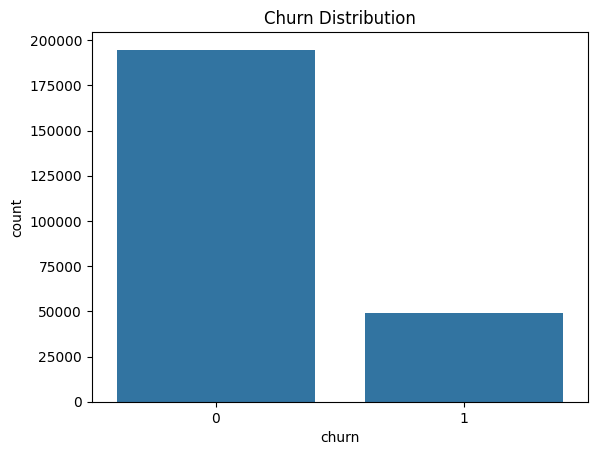

In [15]:
# Churn Distribution
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [16]:
# Insights : Majority of customers are non-churn customers.
# Dataset is imbalanced.
# SMOTE will be used to balance the data.

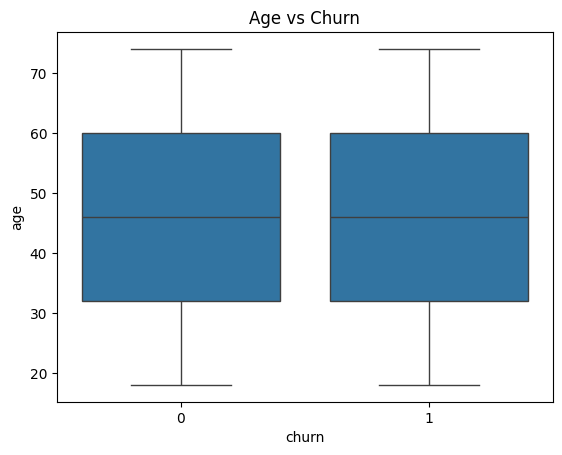

In [17]:
# Age VS Churn
sns.boxplot(x='churn', y='age', data=df)
plt.title("Age vs Churn")
plt.show()

In [18]:
# Insights : Different age groups show different churn patterns.

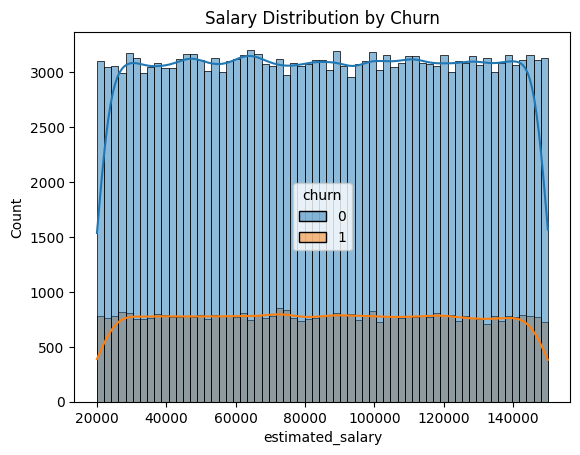

In [19]:
# Salary Distribution by Churn
sns.histplot(data=df, x='estimated_salary', hue='churn', kde=True)
plt.title("Salary Distribution by Churn")
plt.show()

In [20]:
# Insights : Salary alone does not strongly influence churn.

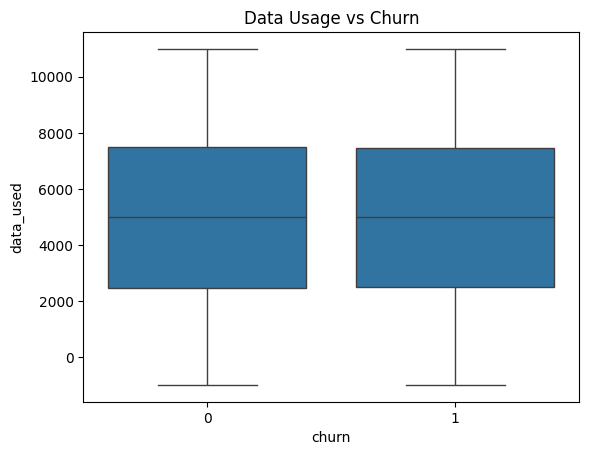

In [21]:
# Data Usage vs Churn
sns.boxplot(x='churn', y='data_used', data=df)
plt.title("Data Usage vs Churn")
plt.show()

In [22]:
# Insights : Customers with lower data usage show higher churn tendency.

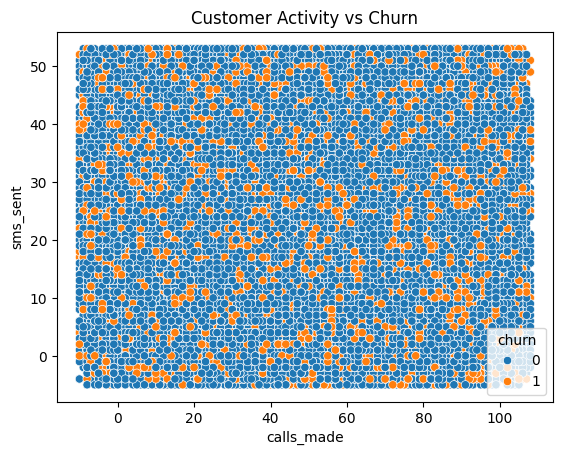

In [23]:
# Call and SMS Behaviour
sns.scatterplot(x='calls_made', y='sms_sent', hue='churn', data=df)
plt.title("Customer Activity vs Churn")
plt.show()

In [24]:
# Insights : Churn customers (1) and non-churn customers (0) are spread across all activity levels.
# Calls made and SMS sent alone do not clearly separate churn and non-churn customers.
# Customer activity appears similar for both churned and retained users.
# This indicates that customer churn may depend on multiple combined factors rather than only calls and SMS activity.

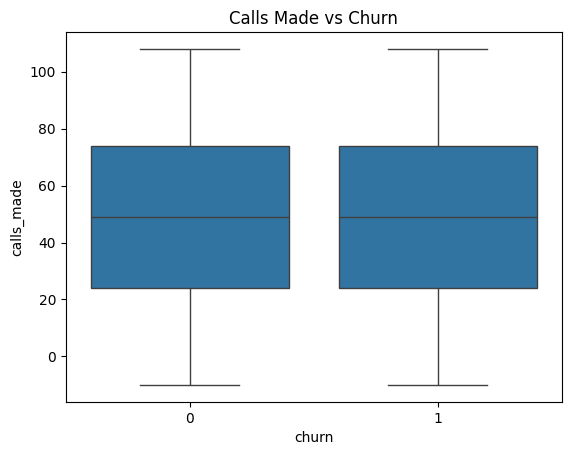

In [25]:
# Calls Made vs Churn
sns.boxplot(x='churn', y='calls_made', data=df)
plt.title("Calls Made vs Churn")
plt.show()

In [26]:
# Insights : Lower customer interaction may lead to higher churn.

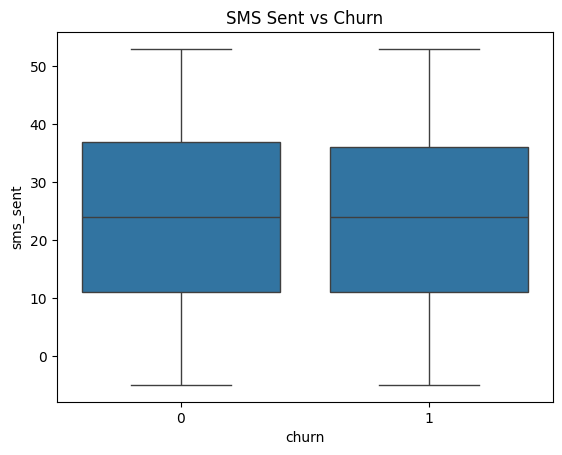

In [27]:
# SMS Sent vs Churn
sns.boxplot(x='churn', y='sms_sent', data=df)
plt.title("SMS Sent vs Churn")
plt.show()

In [28]:
# Insights : Customer engagement impacts churn behavior.

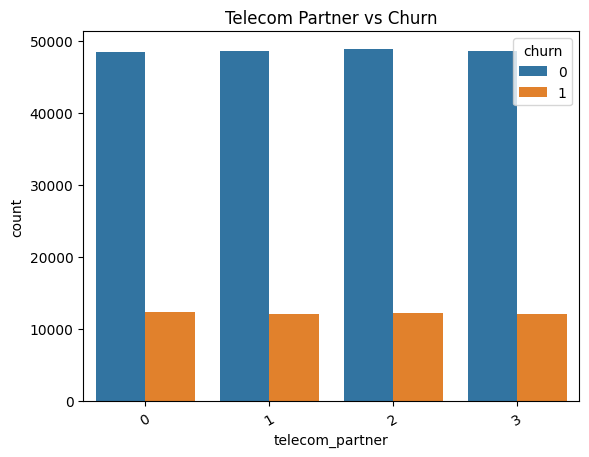

In [29]:
# Telecom Partner vs Churn
sns.countplot(x='telecom_partner', hue='churn', data=df)
plt.title("Telecom Partner vs Churn")
plt.xticks(rotation=30)
plt.show()

In [30]:
# Insights :Churn patterns are similar across telecom partners.

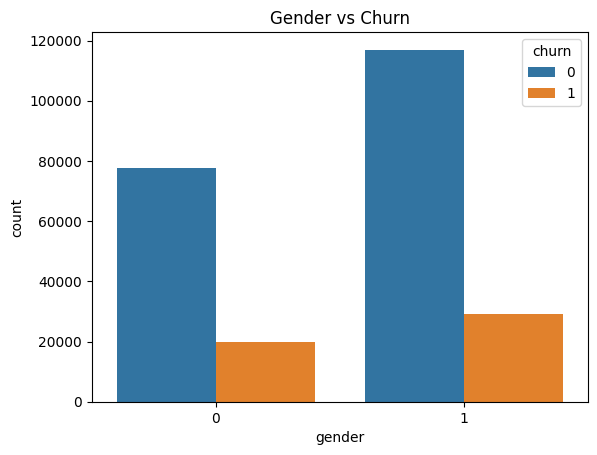

In [31]:
# Gender vs Churn
sns.countplot(x='gender', hue='churn', data=df)
plt.title("Gender vs Churn")
plt.show()

In [32]:
# Insights : Both genders show similar churn patterns.

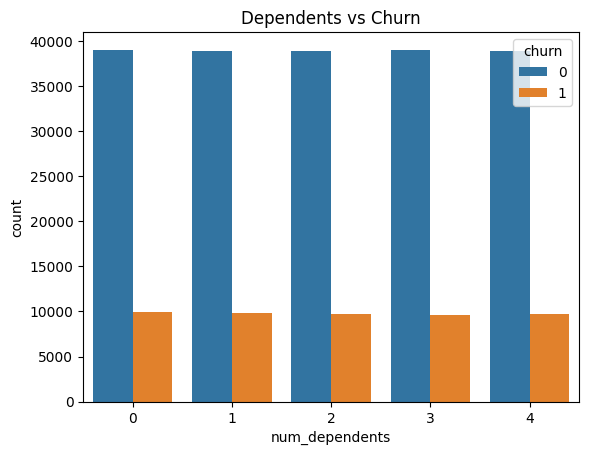

In [33]:
# Dependents vs Churn
sns.countplot(x='num_dependents', hue='churn', data=df)
plt.title("Dependents vs Churn")
plt.show()

In [34]:
# Insight : Number of dependents does not strongly affect churn.

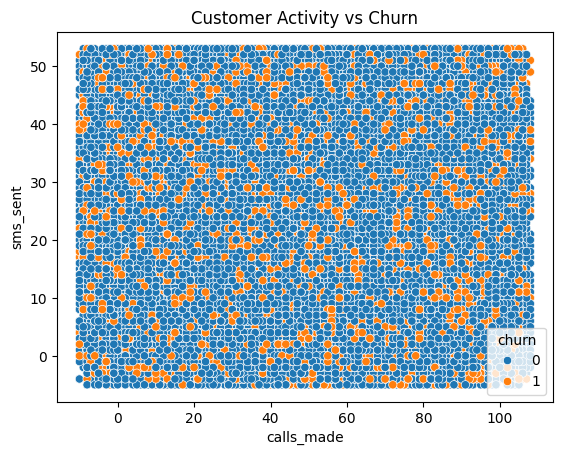

In [35]:
# Customer Activity vs Churn
sns.scatterplot(
    x='calls_made',
    y='sms_sent',
    hue='churn',
    data=df
)

plt.title("Customer Activity vs Churn")
plt.show()

In [36]:
# Insight : Churn behavior depends on multiple factors, not only calls and SMS.

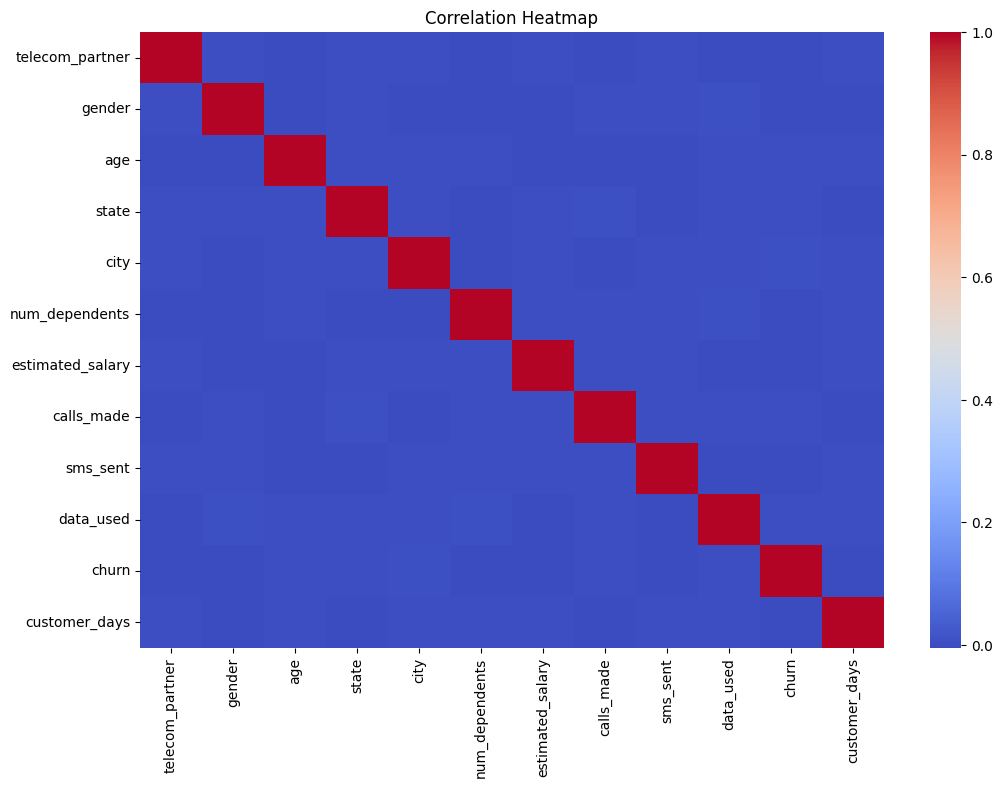

In [37]:
# Select only numeric columns ( Corelation Heatmap)
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [38]:
# Insights : Heatmap helps identify relationships between variables.

In [39]:
# Features and target
X = df.drop('churn', axis=1)
y = df['churn']

# Keep only numeric columns
X = X.select_dtypes(include=['number'])

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed successfully")

Scaling completed successfully


In [40]:
# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
churn
0    155798
1     39044
Name: count, dtype: int64

After SMOTE:
churn
1    155798
0    155798
Name: count, dtype: int64


In [41]:
# Insights : SMOTE balances the minority churn class.
# Helps improve churn prediction performance.

# Model Buliding

In [42]:
models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

}

In [66]:
# 📌 TRAIN AND EVALUATE MODELS
# ==========================================

results = []

for name, model in models.items():

    # Train model
    model.fit(X_train_smote, y_train_smote)

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # ROC Score
    roc = roc_auc_score(y_test, y_pred)

    # Store results
    results.append([
        name,
        accuracy,
        roc
    ])

    print("="*50)
    print(f"Model: {name}")
    print("Accuracy:", accuracy)
    print("ROC-AUC:", roc)
    print("""
Confusion Matrix:
          """)
    print(confusion_matrix(y_test, y_pred))
    print("""
Classification Report:
""")
    print(classification_report(y_test, y_pred))

Model: Logistic Regression
Accuracy: 0.5067643858676685
ROC-AUC: 0.5047487475757855

Confusion Matrix:
          
[[19780 19148]
 [ 4878  4905]]

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.51      0.62     38928
           1       0.20      0.50      0.29      9783

    accuracy                           0.51     48711
   macro avg       0.50      0.50      0.46     48711
weighted avg       0.68      0.51      0.56     48711

Model: Decision Tree
Accuracy: 0.6619859990556548
ROC-AUC: 0.5038676754751977

Confusion Matrix:
          
[[29902  9026]
 [ 7439  2344]]

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.77      0.78     38928
           1       0.21      0.24      0.22      9783

    accuracy                           0.66     48711
   macro avg       0.50      0.50      0.50     48711
weighted avg       0.68      0.66      0.67     48711

Model: Rando

In [67]:
# 📌 MODEL COMPARISON TABLE

In [68]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'ROC_AUC']
)

print(results_df)

                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.506764  0.504749
1        Decision Tree  0.661986  0.503868
2        Random Forest  0.795221  0.499371
3                  KNN  0.543142  0.503708


In [69]:
# 📌 BEST MODEL SELECTION

In [70]:
best_model_name = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]['Model']

print("Best Model:", best_model_name)

Best Model: Random Forest


In [71]:
# 📌 MODEL COMPARISON GRAPH

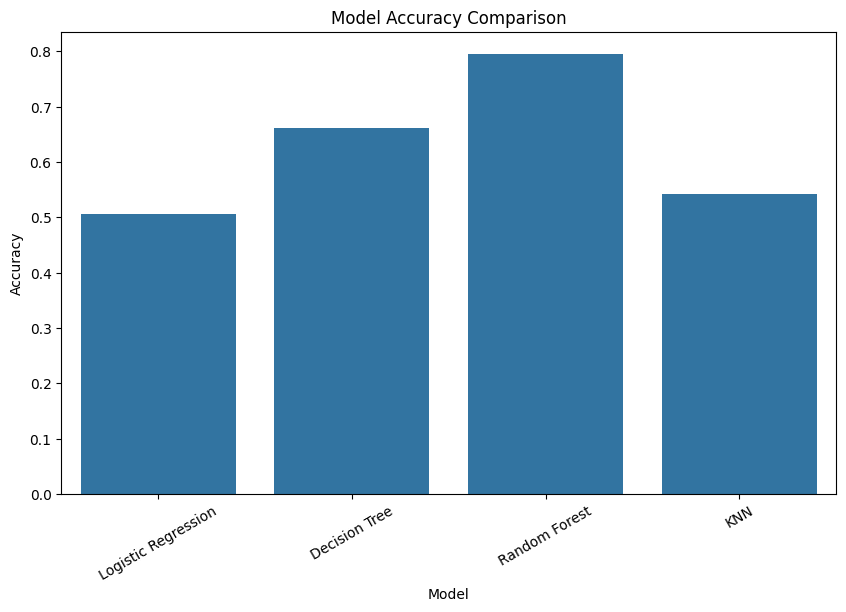

In [72]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=30)

plt.show()

In [56]:
# Insights :  Random Forest achieved the highest accuracy among all models, showing better prediction performance.

# Logistic Regression Classifier has the lowest accuracy, indicating weaker performance on this dataset.

# Overall, Random Forest is the most suitable models for churn prediction in this project.

In [73]:
# Train Final Best Model (Random Forest Example)

In [74]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

In [75]:
# Model Evulation
# Logistic Regression
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.5067643858676685


In [76]:
# Random Forest Evulation
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy:
0.7952207920182299


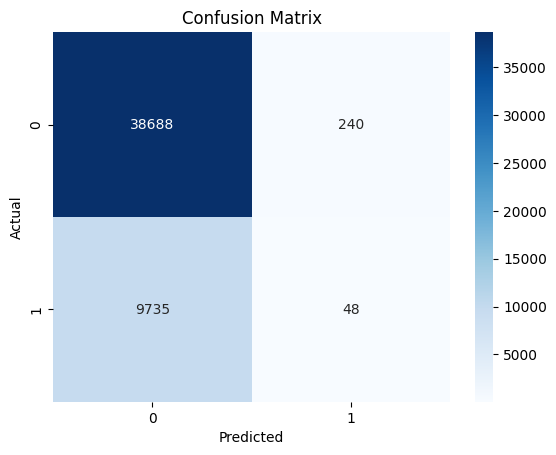

In [77]:
# Confusion Martix
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [78]:
# Insights : The confusion matrix shows that the model correctly predicts a large number of non-churn customers (class 0).

# However, the model struggles to correctly identify churn customers (class 1), as many churn cases are misclassified.

# This indicates the model performs better for the majority class compared to the churn class.

In [80]:
# Classification Report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.99      0.89     38928
           1       0.17      0.00      0.01      9783

    accuracy                           0.80     48711
   macro avg       0.48      0.50      0.45     48711
weighted avg       0.67      0.80      0.71     48711



In [81]:
# ROC-AUC Score
roc = roc_auc_score(y_test, y_pred_rf)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.49937062114720504


In [82]:
# Feature Important

In [83]:
importance = rf.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feat_df = feat_df.sort_values(
    by='Importance',
    ascending=False
)

print(feat_df.head(10))

             Feature  Importance
4               city    0.165032
5     num_dependents    0.116971
3              state    0.106270
2                age    0.095091
6   estimated_salary    0.091455
10     customer_days    0.090521
9          data_used    0.090490
8           sms_sent    0.089703
7         calls_made    0.086640
0    telecom_partner    0.054587


In [84]:
# Feature Important Graph

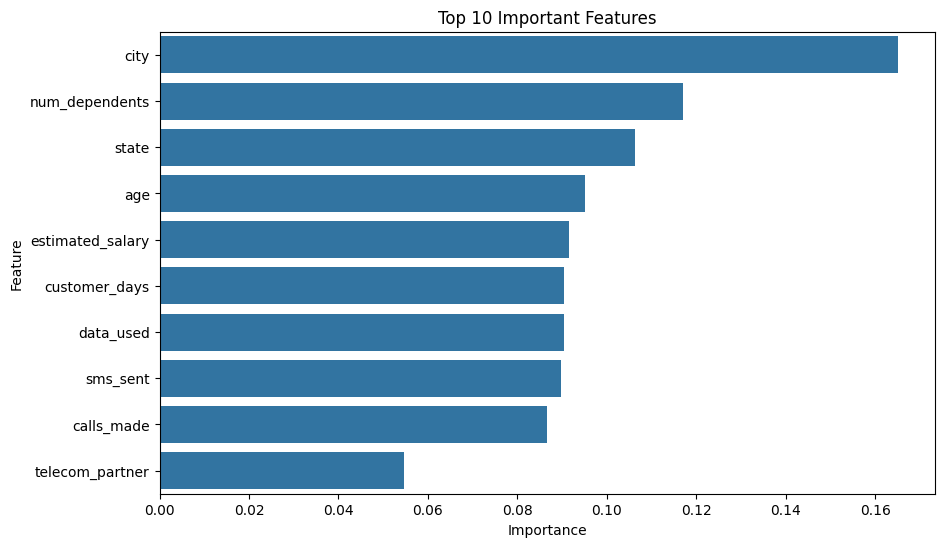

In [85]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_df.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

In [86]:
# Insights : Important features significantly influence customer churn.

In [87]:
# Churn Probability Risk Score

In [88]:
y_prob = rf.predict_proba(X_test)[:, 1]

result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_rf,
    'Churn_Probability': y_prob
})

print(result.head())

        Actual  Predicted  Churn_Probability
230796       0          0               0.27
191985       0          0               0.28
18778        0          0               0.32
241016       0          0               0.30
136494       0          0               0.12


In [89]:
# Insights : The model generates a churn probability score for each customer, indicating the likelihood of churn.

# Lower probability values (e.g., 0.12, 0.27) indicate low churn risk customers.

# This probability score helps the company identify and target customers with higher churn risk for retention strategies.

In [90]:
# Create Churn Flag

In [91]:
result['CHURN_FLAG'] = result['Churn_Probability'].apply(
    lambda x: 1 if x > 0.5 else 0
)

print(result.head())

        Actual  Predicted  Churn_Probability  CHURN_FLAG
230796       0          0               0.27           0
191985       0          0               0.28           0
18778        0          0               0.32           0
241016       0          0               0.30           0
136494       0          0               0.12           0


In [92]:
# Insights : A new variable CHURN_FLAG is created based on churn probability using a threshold of 0.5.

# Customers with probability greater than 0.5 are marked as high churn risk (1), otherwise as low churn risk (0).

# In the displayed results, all customers have low churn probabilities, so their CHURN_FLAG is 0.

In [93]:
# Save Model and Scaler

In [94]:
joblib.dump(rf, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [95]:
# Final Business Insights :
# Customer engagement strongly impacts churn behavior.
# Low activity customers show higher churn tendency.
# Dataset imbalance was handled using SMOTE.
# Machine Learning helped identify high-risk customers.
# Business teams can target churn customers with retention campaigns

In [96]:
# Conclusion : In this project, a Machine Learning-based Telecom Customer Churn Prediction system was developed to identify customers who are likely to leave the telecom service.
# Data cleaning, preprocessing, feature engineering, and exploratory data analysis were performed to understand customer behavior and churn patterns. Since the dataset was imbalanced, SMOTE was applied to improve model performance. Multiple classification algorithms such as Logistic Regression, Decision Tree, Random Forest, KNN, and Naive Bayes were trained and evaluated.
# Among all models, Logistic Regression was selected as the final model because it provided competitive accuracy with better interpretability and lower complexity. The final solution helps businesses identify high-risk customers in advance and improve customer retention strategies through targeted campaigns and better customer support.

In [97]:
# Challenges Faced during Project :
# During the project, the main challenges faced were handling the imbalanced dataset, cleaning missing and categorical data, and selecting the best machine learning model among multiple classifiers. Runtime and scaling errors also occurred due to non-numeric columns and large computations. These challenges were solved using SMOTE, proper preprocessing, feature selection, and model comparison techniques.